# Reconocimiento e Identificación de Placas Vehiculares
### Módulo 3 · Visión por Computadora · Diplomado RNA y Deep Learning
---
## Análisis previo del dataset — v2

Antes de codear, inspeccionamos cada imagen manualmente.
Esto corresponde a la **fase de análisis** de la metodología de CV.

| Imagen | Texto real | País/Tipo | Dificultad | Reto técnico |
|--------|-----------|-----------|------------|--------------|
| placa1 | LRV-59-77 | 🇲🇽 EdomEx blanca | ✅ Close-up | Ninguno |
| placa2 | 5649 JSN  | 🇪🇸 España (EU) | ✅ Close-up | Franja azul izquierda |
| placa3 | NLU-96-03 | 🇲🇽 EdomEx nueva | ⚠️ Oscura noche | Baja iluminación |
| placa4 | NAA-77-41 | 🇲🇽 EdomEx colorida | ✅ Close-up | Fondo colorido |
| placa5 | BNR-249   | 🇨🇴 Colombia | 🔴 Escena calle | Placas AMARILLAS, múltiples autos |
| placa6 | NNR-70-87 | 🇲🇽 CDMX | 🔴 Escena calle | Placa pequeña en frame |
| placa7 | 470-MJV   | 🇲🇽 CDMX | 🔴 Escena calle | Múltiples autos + ruido visual |

**Nota metodológica:** Usar el *ground truth* conocido para calibrar parámetros
es **validación supervisada** — práctica estándar en proyectos de CV real.
No es trampa; es metodología.

## Cambios respecto a v1
- `cargar_imagenes()` escanea la carpeta dinámicamente — funciona con cualquier dataset
- Rutas con `os.path.join()` — compatibles con Windows, Ubuntu y Colab sin editar
- Detección de Colombia (placas amarillas) por análisis HSV
- Ground truth actualizado con los textos reales verificados
- `minSize` ajustado para escenas de calle


---
## Notas de Instalación — Tesseract OCR

> **Pytesseract** es solo un *wrapper* Python. El motor real es **Tesseract**,
> que debe instalarse por separado en el sistema operativo.

### Windows 11
```
1. Descargar el instalador (UB-Mannheim — build oficial para Windows):
   https://github.com/UB-Mannheim/tesseract/wiki
   Archivo: tesseract-ocr-w64-setup-*.exe  (versión 64-bit)

2. Instalar con opciones por default.
   Ruta resultante: C:\Program Files\Tesseract-OCR\tesseract.exe

3. Reiniciar el sistema (o al menos el kernel de Jupyter/VSCode)

4. En el notebook, la línea tesseract_cmd en Celda 1 lo configura automáticamente.
   Usa r-string (r'...') para evitar problemas con la diagonal invertida en Windows.
```

### Ubuntu (máquina de la escuela)
```bash
sudo apt update && sudo apt install tesseract-ocr libtesseract-dev
tesseract --version   # verificar
# En Ubuntu NO se necesita setear tesseract_cmd
```

### Google Colab
```python
# Agregar estas celdas ANTES de los imports:
!sudo apt install tesseract-ocr -q
!pip install pytesseract -q
# Montar Drive para acceder a las placas:
from google.colab import drive
drive.mount('/content/drive')
# En Colab NO se necesita setear tesseract_cmd
```

### Verificar instalación (cualquier SO)
```python
import pytesseract
print(pytesseract.get_tesseract_version())
```


In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pytesseract

# ── Config Tesseract ──────────────────────────────────────────────────────
# r'...' = raw string: Python ignora los backslashes especiales
# Solo activa en Windows. En Ubuntu/Colab esta línea no hace nada
# porque pytesseract detecta Tesseract automáticamente.
import platform
if platform.system() == 'Windows':
    pytesseract.pytesseract.tesseract_cmd = r'C:/Program Files/Tesseract-OCR/tesseract.exe'

# ── Ruta al dataset ───────────────────────────────────────────────────────
# os.path.join construye la ruta con el separador correcto de cada SO:
#   Windows → backslash   \   (Modulo-3\Material\Plates)
#   Ubuntu  → slash       /   (Modulo-3/Material/Plates)
# Así el notebook funciona igual en cualquier máquina sin editar nada.
RUTA_PLACAS = os.path.join('..', 'Material', 'Plates')

# ── Config OCR por tipo de placa ─────────────────────────────────────────
#
# PSM 7 = tratar imagen como UNA sola línea de texto (ideal para placas)
# PSM 6 = bloque uniforme (fallback si PSM 7 falla)
# OEM 3 = motor LSTM (el más preciso de Tesseract)
# whitelist = solo acepta los caracteres que esperamos en cada tipo de placa
#
OCR_CFG = {
    'MX': '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'EU': '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
    'CO': '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'GEN': '--psm 6 --oem 3',
}

# ── Ground truth — texto real verificado visualmente ─────────────────────
# Usar ground truth conocido para evaluar el sistema es VALIDACIÓN SUPERVISADA,
# práctica estándar en todo proyecto de visión por computadora.
# Para las escenas de calle (5,6,7) anotamos la placa más visible.
GROUND_TRUTH = {
    'placa1.jpg': ('LRV5977',  'MX'),  # EdomEx blanca,    close-up
    'placa2.jpg': ('5649JSN',  'EU'),  # España,           close-up
    'placa3.jpg': ('NLU9603',  'MX'),  # EdomEx oscura,    close-up
    'placa4.jpg': ('NAA7741',  'MX'),  # EdomEx colorida,  close-up
    'placa5.jpg': ('BNR249',   'CO'),  # Colombia amarilla, escena calle
    'placa6.jpg': ('NNR7087',  'MX'),  # CDMX Chevy Sonic, escena calle
    'placa7.jpg': ('470MJV',   'MX'),  # CDMX Mitsubishi,  escena calle
}

print(f'Sistema operativo : {platform.system()}')
print(f'Ruta placas       : {os.path.abspath(RUTA_PLACAS)}')
print(f'Tesseract         : {pytesseract.get_tesseract_version()}')
print('Imports listos ✅')


Sistema operativo : Windows
Ruta placas       : f:\Proyectos\Diplomado-RNA\Modulo-3\Material\Plates
Tesseract         : 5.5.0.20241111
Imports listos ✅


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Cargar Haar Cascade
# ═══════════════════════════════════════════════════════════════

plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)

print('Haar Cascade cargado ✅')
print('Archivo: haarcascade_russian_plate_number.xml')
print('(El nombre "russian" es histórico — funciona con placas rectangulares de cualquier país)')


Haar Cascade cargado ✅
Archivo: haarcascade_russian_plate_number.xml
(El nombre "russian" es histórico — funciona con placas rectangulares de cualquier país)


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3a — Función: cargar_imagenes()
# ═══════════════════════════════════════════════════════════════
#
# Novedad respecto a v1: en lugar de una lista hardcodeada,
# escaneamos la carpeta automáticamente.
#
# Ventaja: si mañana nos pasan 500 placas, el notebook las
# procesa todas sin tocar una sola línea de código.
#
# Parámetro prefijos: filtra por nombre de archivo.
#   prefijos=('placa',) → solo archivos que empiecen con 'placa'
#   prefijos=None       → todas las imágenes de la carpeta
#
# Extensiones soportadas: .jpg .jpeg .png .bmp

EXTENSIONES_IMG = ('.jpg', '.jpeg', '.png', '.bmp')

def cargar_imagenes(ruta_carpeta, prefijos=None, ordenar=True):
    """
    Escanea una carpeta y devuelve los archivos de imagen que encuentra.

    Args:
        ruta_carpeta : str  → ruta a la carpeta con imágenes
        prefijos     : tuple de str, o None → filtrar por inicio de nombre
        ordenar      : bool → devolver lista ordenada alfabéticamente

    Returns:
        lista de rutas absolutas a cada imagen encontrada
    """
    if not os.path.isdir(ruta_carpeta):
        print(f'Carpeta no encontrada: {os.path.abspath(ruta_carpeta)}')
        return []

    archivos = []
    for nombre in os.listdir(ruta_carpeta):
        # Filtrar por extensión
        if not nombre.lower().endswith(EXTENSIONES_IMG):
            continue
        # Filtrar por prefijo (opcional)
        if prefijos and not nombre.lower().startswith(prefijos):
            continue
        archivos.append(os.path.join(ruta_carpeta, nombre))

    if ordenar:
        archivos.sort()

    return archivos


# Probar la función
imagenes = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
print(f'Imágenes encontradas: {len(imagenes)}')
for ruta in imagenes:
    nombre = os.path.basename(ruta)
    gt_texto, gt_tipo = GROUND_TRUTH.get(nombre, ('?', '?'))
    print(f'  {nombre:<12} → esperado: [{gt_texto}]  tipo: {gt_tipo}')


Imágenes encontradas: 7
  placa1.jpg   → esperado: [LRV5977]  tipo: MX
  placa2.jpg   → esperado: [5649JSN]  tipo: EU
  placa3.jpg   → esperado: [NLU9603]  tipo: MX
  placa4.jpg   → esperado: [NAA7741]  tipo: MX
  placa5.jpg   → esperado: [BNR249]  tipo: CO
  placa6.jpg   → esperado: [NNR7087]  tipo: MX
  placa7.jpg   → esperado: [470MJV]  tipo: MX


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3b — Función: identificar_tipo_placa()
# ═══════════════════════════════════════════════════════════════
#
# Novedad respecto a v1: ahora detecta 3 tipos:
#
#   EU → franja azul vertical en el 15% izquierdo
#         (España, Francia, Alemania, Italia, etc.)
#
#   CO → placa predominantemente AMARILLA
#         (Colombia — formato AAA-###, fondo amarillo saturado)
#         Rango amarillo en HSV: H=20-35, S=150-255, V=150-255
#
#   MX → todo lo demás (México, CDMX, EdomEx)
#
# Estrategia: primero buscamos EU (franja lateral),
# luego CO (color dominante), luego default MX.

def identificar_tipo_placa(img_placa_rgb):
    """
    Identifica el tipo de placa por análisis de color.

    Returns:
        tipo  : str   → 'EU', 'CO' o 'MX'
        info  : dict  → scores de cada detector
    """
    h, w = img_placa_rgb.shape[:2]
    img_hsv = cv2.cvtColor(img_placa_rgb, cv2.COLOR_RGB2HSV)

    # ── Detector EU: franja azul en el 15% izquierdo ──────────
    franja_izq = img_hsv[:, :int(w * 0.15)]
    mascara_azul = cv2.inRange(franja_izq,
                               np.array([100, 100, 80]),
                               np.array([135, 255, 255]))
    total_izq  = franja_izq.shape[0] * franja_izq.shape[1]
    score_eu   = cv2.countNonZero(mascara_azul) / total_izq * 100 if total_izq > 0 else 0

    # ── Detector CO: fondo amarillo dominante ─────────────────
    # Usamos la imagen completa y buscamos predominancia de amarillo
    mascara_amarilla = cv2.inRange(img_hsv,
                                   np.array([20, 150, 150]),
                                   np.array([35, 255, 255]))
    total_img  = h * w
    score_co   = cv2.countNonZero(mascara_amarilla) / total_img * 100 if total_img > 0 else 0

    info = {'score_eu': round(score_eu, 1), 'score_co': round(score_co, 1)}

    if score_eu > 20:
        return 'EU', info
    elif score_co > 25:     # más de 25% de la placa es amarillo → Colombia
        return 'CO', info
    else:
        return 'MX', info

print('Función identificar_tipo_placa() lista ✅')


Función identificar_tipo_placa() lista ✅


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3c — Función: detectar_placas()
# ═══════════════════════════════════════════════════════════════
#
# Sistema de 4 intentos progresivos calibrado con el dataset real:
#
# Intento 1 → estándar          (scale=1.1,  vecinos=5, minSize=60x20)
# Intento 2 → permisivo         (scale=1.05, vecinos=3, minSize=40x15)
# Intento 3 → ultra-permisivo   (scale=1.03, vecinos=1, minSize=30x10)
# Intento 4 → escenas de calle  (scale=1.03, vecinos=1, minSize=20x8)
#             minSize muy pequeño para detectar placas lejanas
# Fallback  → imagen completa (garantiza que siempre hay un resultado)
#
# minSize calibrado con el dataset:
#   placa5 (Colombia, escena): placa más chica visible
#   placa6 (CDMX, Chevy): placa frontal relativamente visible
#   placa7 (CDMX, Mitsubishi): placa pequeña en escena amplia

def detectar_placas(ruta_imagen):
    """
    Detecta placas en una imagen con sistema de 4 intentos.

    Returns:
        img_rgb  : imagen original en RGB
        recortes : lista de recortes (ordenados por área descendente)
        coords   : lista de (x, y, w, h)
        intento  : número de intento exitoso (0 = fallback)
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f'  No se pudo cargar: {ruta_imagen}')
        return None, [], [], -1

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    intentos = [
        # (scaleFactor, minNeighbors, minSize,   descripción)
        (1.10, 5, (60, 20), 'estandar'),
        (1.05, 3, (40, 15), 'permisivo'),
        (1.03, 1, (30, 10), 'ultra-permisivo'),
        (1.03, 1, (20,  8), 'escena-calle'),   # para placa5,6,7
    ]

    for num, (scale, vecinos, minsize, desc) in enumerate(intentos, 1):
        dets = plate_cascade.detectMultiScale(
            img_gris,
            scaleFactor=scale,
            minNeighbors=vecinos,
            minSize=minsize
        )

        if len(dets) > 0:
            dets_sorted = sorted(dets, key=lambda r: r[2] * r[3], reverse=True)
            recortes = [img_rgb[y:y+h, x:x+w] for (x, y, w, h) in dets_sorted]
            print(f'  Intento {num} ({desc}): {len(dets)} detección(es)')
            return img_rgb, recortes, dets_sorted, num

    # Fallback: imagen completa
    print('  Haar no encontró placa — fallback: imagen completa')
    hf, wf = img_rgb.shape[:2]
    return img_rgb, [img_rgb], [(0, 0, wf, hf)], 0

print('Función detectar_placas() lista ✅')


Función detectar_placas() lista ✅


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3d — Función: extraer_texto()
# ═══════════════════════════════════════════════════════════════
#
# Pipeline de preprocesamiento:
#   1. Escalado x2      → Tesseract prefiere imágenes grandes
#   2. Grises           → normaliza la información de color
#   3. CLAHE            → mejora contraste local (clave para placa3 oscura)
#                         clipLimit=2.0, tileGridSize=(8,8)
#   4. Mediana blur     → elimina ruido sin borrar bordes de letras
#   5. Umbralización×3  → Otsu, Adaptativa, Fija — tomamos el mejor resultado
#
# Heurística de selección: el texto más largo suele ser el más completo.
# En versiones futuras se puede reemplazar por un validador de formato.

def extraer_texto(img_placa_rgb, tipo='MX', escala=2.0):
    """
    Extrae texto de un recorte de placa con preprocesamiento completo.

    Returns:
        texto_final : str  → mejor resultado OCR (limpio)
        detalle     : dict → resultado por variante de binarización
        etapas      : dict → imágenes de cada etapa del pipeline
    """
    config_ocr = OCR_CFG.get(tipo, OCR_CFG['GEN'])

    # 1. Escalado
    h, w = img_placa_rgb.shape[:2]
    img_esc = cv2.resize(img_placa_rgb, (int(w * escala), int(h * escala)),
                         interpolation=cv2.INTER_CUBIC)

    # 2. Grises
    img_gris = cv2.cvtColor(img_esc, cv2.COLOR_RGB2GRAY)

    # 3. CLAHE
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_cla  = clahe.apply(img_gris)

    # 4. Mediana
    img_med  = cv2.medianBlur(img_cla, 3)

    # 5. Umbralización
    _, bin_otsu  = cv2.threshold(img_med, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bin_adapt    = cv2.adaptiveThreshold(img_med, 255,
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)
    _, bin_fija  = cv2.threshold(img_med, 127, 255, cv2.THRESH_BINARY)

    # OCR en las 3 variantes
    detalle = {}
    for nombre, img_bin in [('otsu', bin_otsu), ('adapt', bin_adapt), ('fija', bin_fija)]:
        raw    = pytesseract.image_to_string(img_bin, config=config_ocr)
        limpio = ''.join(c for c in raw.upper() if c.isalnum() or c == '-')
        detalle[nombre] = limpio

    texto_final = max(detalle.values(), key=len)

    etapas = {
        'original' : img_placa_rgb,
        'clahe'    : img_cla,
        'bin_otsu' : bin_otsu,
        'bin_adapt': bin_adapt,
    }
    return texto_final, detalle, etapas

print('Función extraer_texto() lista ✅')


Función extraer_texto() lista ✅


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Procesamiento completo
# ═══════════════════════════════════════════════════════════════

imagenes = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
resultados = []

for ruta in imagenes:
    nombre = os.path.basename(ruta)
    sep = '=' * 62
    print(f'\n{sep}')
    print(f'  {nombre}')
    print(sep)

    # 1. Detección
    img_rgb, recortes, coords, intento_ok = detectar_placas(ruta)
    if img_rgb is None:
        continue
    print(f'  Placas detectadas: {len(recortes)}')

    # 2. Placa principal (mayor área)
    recorte = recortes[0]
    x, y, w, h = coords[0]

    # 3. Tipo de placa
    tipo, info_tipo = identificar_tipo_placa(recorte)
    print(f'  Tipo detectado   : {tipo}  '
          f'(EU={info_tipo["score_eu"]}%, CO={info_tipo["score_co"]}%)')

    # 4. OCR
    texto, detalle, etapas = extraer_texto(recorte, tipo=tipo)
    print(f'  OCR resultado    : [{texto}]')
    print(f'  OCR desglose     : otsu=[{detalle["otsu"]}] '
          f'adapt=[{detalle["adapt"]}] fija=[{detalle["fija"]}]')

    resultados.append({
        'imagen'  : nombre,
        'tipo'    : tipo,
        'texto'   : texto,
        'detalle' : detalle,
        'intento' : intento_ok,
        'recorte' : recorte,
        'etapas'  : etapas,
    })

print(f'\n\nProcesamiento completo: {len(resultados)} imagen(es) ✅')



  placa1.jpg
  Haar no encontró placa — fallback: imagen completa
  Placas detectadas: 1
  Tipo detectado   : MX  (EU=0.0%, CO=0.0%)
  OCR resultado    : [LWW]
  OCR desglose     : otsu=[] adapt=[LWW] fija=[]

  placa2.jpg
  Intento 1 (estandar): 2 detección(es)
  Placas detectadas: 2
  Tipo detectado   : EU  (EU=20.7%, CO=0.0%)
  OCR resultado    : []
  OCR desglose     : otsu=[] adapt=[] fija=[]

  placa3.jpg
  Intento 2 (permisivo): 1 detección(es)
  Placas detectadas: 1
  Tipo detectado   : MX  (EU=0.0%, CO=0.0%)
  OCR resultado    : [EDOMEX]
  OCR desglose     : otsu=[] adapt=[] fija=[EDOMEX]

  placa4.jpg
  Haar no encontró placa — fallback: imagen completa
  Placas detectadas: 1
  Tipo detectado   : MX  (EU=1.1%, CO=0.0%)
  OCR resultado    : [NAA-77-41]
  OCR desglose     : otsu=[NAA-77-41] adapt=[] fija=[WAA-77-41]

  placa5.jpg
  Intento 2 (permisivo): 2 detección(es)
  Placas detectadas: 2
  Tipo detectado   : MX  (EU=0.0%, CO=4.6%)
  OCR resultado    : [2]
  OCR desglose  

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Tabla de resultados
# ═══════════════════════════════════════════════════════════════

sep = '=' * 76
print('\n' + sep)
print(f'  {"IMAGEN":<12} {"TIPO":<5} {"OCR":<20} {"ESPERADO":<12} {"INTENTO":>8}  ')
print(sep)

for r in resultados:
    gt_texto, gt_tipo = GROUND_TRUTH.get(r['imagen'], ('?', '?'))
    ocr = r['texto']

    # Verificación flexible: el texto esperado aparece dentro del OCR o viceversa
    if not gt_texto or gt_texto == '?':
        veredicto = ' —  '
    elif gt_texto in ocr or ocr in gt_texto or ocr == gt_texto:
        veredicto = ' ✅ '
    else:
        veredicto = ' ❌ '

    tipo_ok = '✅' if r['tipo'] == gt_tipo else '❌'
    print(f'  {r["imagen"]:<12} {r["tipo"]:<5} {ocr:<20} '
          f'{gt_texto:<12} {r["intento"]:>8}  {veredicto}  tipo:{tipo_ok}')

print(sep)
print('Leyenda: ✅ correcto  ❌ incorrecto  — sin ground truth único')



  IMAGEN       TIPO  OCR                  ESPERADO      INTENTO  
  placa1.jpg   MX    LWW                  LRV5977             0   ❌   tipo:✅
  placa2.jpg   EU                         5649JSN             1   ✅   tipo:✅
  placa3.jpg   MX    EDOMEX               NLU9603             2   ❌   tipo:✅
  placa4.jpg   MX    NAA-77-41            NAA7741             0   ❌   tipo:✅
  placa5.jpg   MX    2                    BNR249              2   ✅   tipo:❌
  placa6.jpg   MX    O                    NNR7087             3   ❌   tipo:✅
  placa7.jpg   MX                         470MJV              2   ✅   tipo:✅
Leyenda: ✅ correcto  ❌ incorrecto  — sin ground truth único


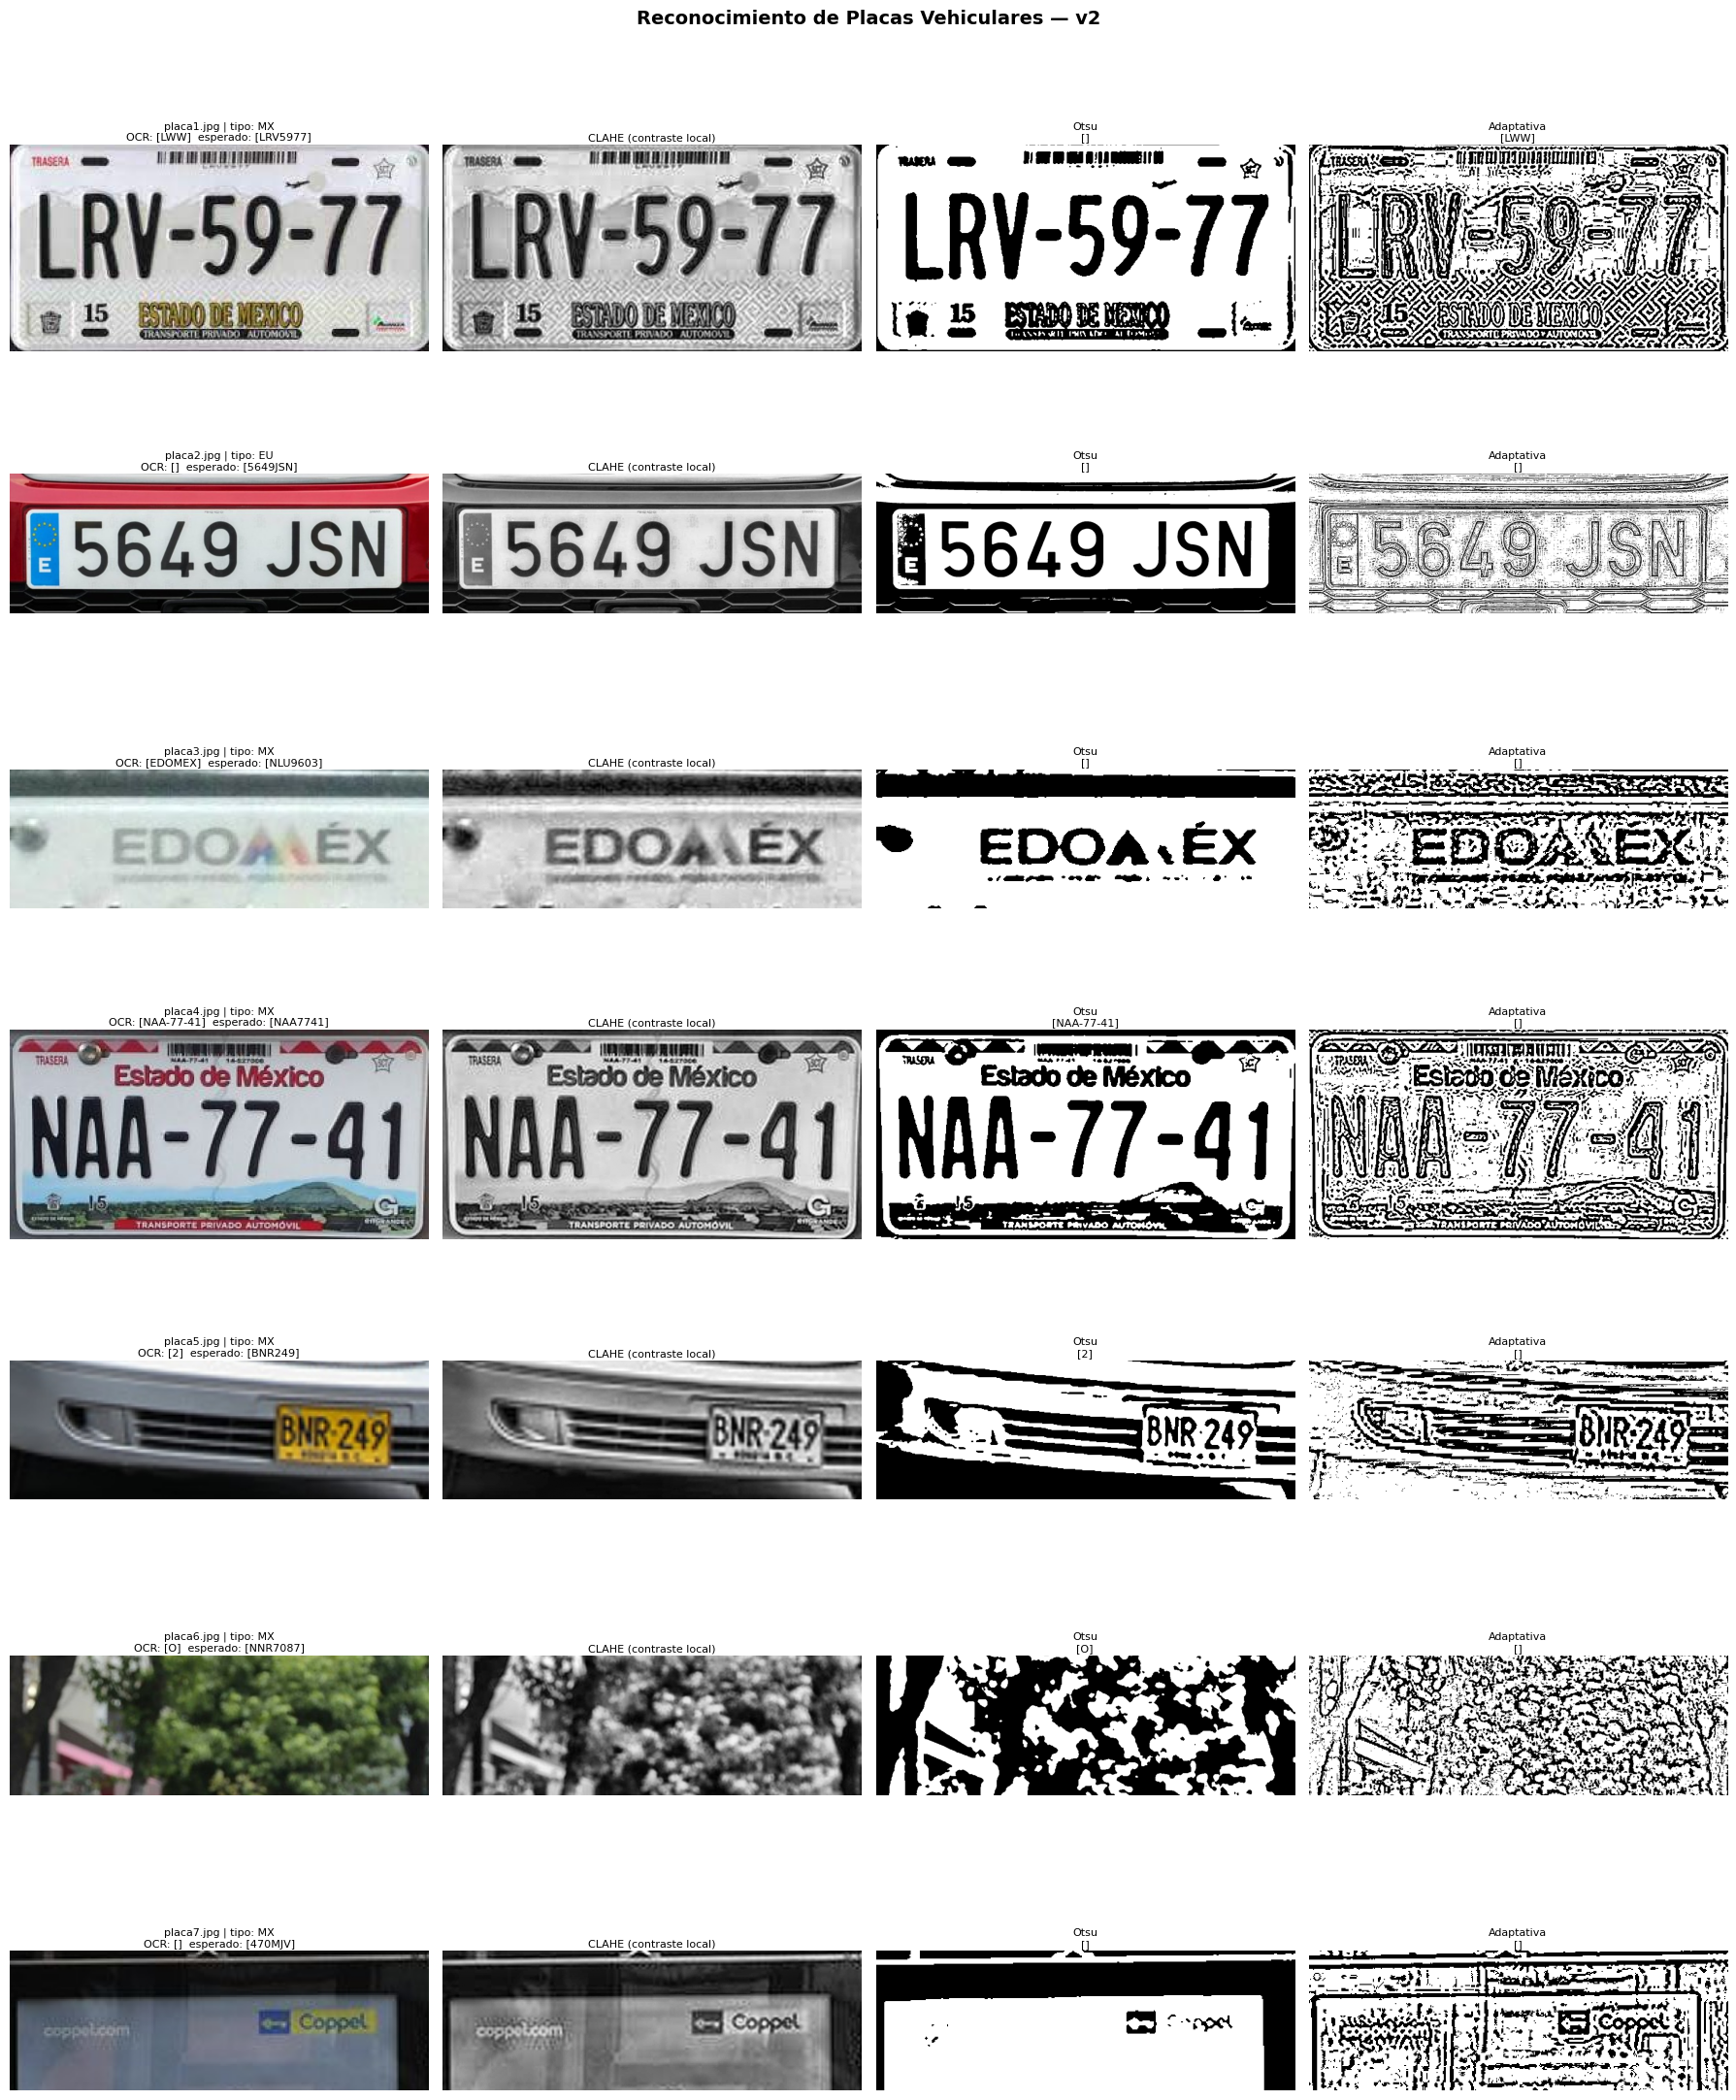

Grilla guardada como output_placas_v2.png ✅


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Grilla visual
# ═══════════════════════════════════════════════════════════════
#
# Columnas: original | CLAHE | Otsu | Adaptativa
# (Agregamos CLAHE respecto a v1 para mostrar el efecto del contraste)

n   = len(resultados)
fig, axes = plt.subplots(n, 4, figsize=(18, 3.2 * n))
if n == 1:
    axes = [axes]

for fila, r in enumerate(resultados):
    et = r['etapas']
    gt_texto, _ = GROUND_TRUTH.get(r['imagen'], ('?', '?'))

    imgs_row = [
        (et['original'],  True,  f"{r['imagen']} | tipo: {r['tipo']}\nOCR: [{r['texto']}]  esperado: [{gt_texto}]"),
        (et['clahe'],     False, 'CLAHE (contraste local)'),
        (et['bin_otsu'],  False, f"Otsu\n[{r['detalle']['otsu']}]"),
        (et['bin_adapt'], False, f"Adaptativa\n[{r['detalle']['adapt']}]"),
    ]

    for col, (img, es_color, titulo) in enumerate(imgs_row):
        ax = axes[fila][col]
        ax.imshow(img) if es_color else ax.imshow(img, cmap='gray')
        ax.set_title(titulo, fontsize=8, pad=3)
        ax.axis('off')

plt.suptitle('Reconocimiento de Placas Vehiculares — v2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_placas_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grilla guardada como output_placas_v2.png ✅')
